**Importing relevant libraries and Pickel Data**

In [1]:
## Importing libraries and packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import pickle
import math

In [2]:
# Open Training pkl file
with open('data/train_data.pkl', 'rb') as f:
    data = pickle.load(f)

# Loading Image and Labels Training Data
images_train = data['images']
labels_train = data['labels']

# Opening Test Data Set 
with open('data/test_data.pkl', 'rb') as g:
    data = pickle.load(g)

images_test = data['images']





**Exploring Pre-November 30th Data**

In [3]:
print("This is the outline of the images training data: ", images_train)
print("This is the outline of the label training data", labels_train)

This is the outline of the images training data:  [[[[ 6  4  0]
   [ 9  5  0]
   [ 8  4  0]
   ...
   [ 9  6  0]
   [ 9  6  0]
   [ 7  4  0]]

  [[11  6  0]
   [ 4  4  0]
   [ 3  3  0]
   ...
   [ 9  6  0]
   [ 6  4  0]
   [ 4  2  0]]

  [[11  6  0]
   [ 4  4  0]
   [ 3  3  0]
   ...
   [ 6  4  0]
   [ 6  4  0]
   [ 4  2  0]]

  ...

  [[ 1  1  0]
   [ 0  0  0]
   [ 0  0  1]
   ...
   [ 5  4  0]
   [ 6  5  0]
   [ 6  5  0]]

  [[ 3  1  1]
   [ 0  0  0]
   [ 0  0  1]
   ...
   [ 6  5  0]
   [ 6  5  0]
   [ 7  6  0]]

  [[10  2  2]
   [ 0  0  1]
   [ 0  0  1]
   ...
   [ 6  5  0]
   [ 7  6  0]
   [ 7  6  0]]]


 [[[11  9  0]
   [ 9  7  0]
   [ 9  7  0]
   ...
   [ 0  0  1]
   [ 0  0  1]
   [ 0  0  1]]

  [[12  9  0]
   [11  7  0]
   [ 9  6  0]
   ...
   [ 0  0  2]
   [ 0  0  1]
   [ 0  0  1]]

  [[ 9  7  0]
   [12  8  0]
   [10  6  0]
   ...
   [ 0  0  1]
   [ 0  0  1]
   [ 0  0  0]]

  ...

  [[ 0  0  3]
   [ 0  0  3]
   [ 0  0  4]
   ...
   [ 0  0  2]
   [ 0  0  1]
   [ 0  0  0]]

  [[

In [4]:
## Exploring shape of the data 
print("This is the shape of the images training data: ", images_train.shape)
print("This is the shape of the label training data", labels_train.shape)
print("This is the shape of the images test data: ", images_test.shape)

## Exploring data type 
print("This is the data type of the image training: ", images_train.dtype)
print("This is the number of unique value for labels training: ", np.unique(labels_train))
print("This is the data type of the image test: ", images_test.dtype)

This is the shape of the images training data:  (1080, 28, 28, 3)
This is the shape of the label training data (1080, 1)
This is the shape of the images test data:  (400, 28, 28, 3)
This is the data type of the image training:  uint8
This is the number of unique value for labels training:  [0 1 2 3 4]
This is the data type of the image test:  uint8


In [5]:
# Seeing class breakdown for labels 
unique, counts = np.unique(labels_train, return_counts=True)
print("Class distribution:")
for u, c in zip(unique, counts):
    print(f"Label {u}: {c} samples")

Class distribution:
Label 0: 486 samples
Label 1: 128 samples
Label 2: 206 samples
Label 3: 194 samples
Label 4: 66 samples


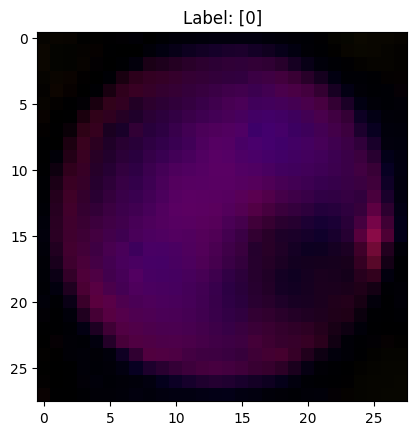

In [6]:
# Plotting Graph to visualize images
plt.imshow(images_train[0], cmap="gray")
plt.title(f"Label: {labels_train[0]}")
plt.show()

In [7]:
print(" The minimum pixel for training: ", images_train.min())
print(" The maximum pixel for training: ", images_train.max())
print(" The Mean pixel for training: ", images_train.mean())
print(" The standard deviation for training: ", images_train.std())

print(" The minimum pixel for test: ", images_test.min())
print(" The maximum pixel for test: ", images_test.max())
print(" The Mean pixel for test: ", images_test.mean())
print(" The standard deviation for test: ", images_test.std())

 The minimum pixel for training:  0
 The maximum pixel for training:  255
 The Mean pixel for training:  37.74362638573948
 The standard deviation for training:  45.53972858040953
 The minimum pixel for test:  0
 The maximum pixel for test:  255
 The Mean pixel for test:  36.420057397959184
 The standard deviation for test:  44.014485738716104


**Investigating Missing Data**

In [8]:
print("The number of missing values in the images training dataset: ", np.isnan(images_train).sum())
print("The number of missing values in the images testing dataset: ", np.isnan(images_test).sum())

The number of missing values in the images training dataset:  0
The number of missing values in the images testing dataset:  0


**Reshaping & Standardizing Data**

In [9]:
# Reshaping training and test data so we can perform Classification Methods 
images_train_rs = images_train.reshape(images_train.shape[0], -1)
y = labels_train.reshape(-1)
images_test_rs = images_test.reshape(images_test.shape[0], -1)

# Performing Normalization on images 
X = images_train_rs/255.0
X_test = images_test_rs/255.0



**Train Test Split**

In [10]:
# Defining Train Test Split function as similar as possible to sklearn
def train_valid_split(X, y, test_size=0.2, random_state=42):
    # Defining random number generator 
    rng = np.random.RandomState(random_state)
    # Defining number of samples and indices 
    n_samples = len(X)
    indices = np.arange(n_samples)
    
    # shuffle in-place exactly like sklearn does
    rng.shuffle(indices)
    
    # Defining test number, test index, and train index 
    n_test = math.ceil(n_samples * test_size)
    test_idx = indices[:n_test]
    train_idx = indices[n_test:]
    
    # Return X and y train and test data 
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

# Calling train_valid split function
X_tr, X_val, y_tr, y_val = train_valid_split(X, y)
# Print number of features and labels 
print("\n These are the features for X_trained here: ", X_tr)
print("\n These are the labels for y_trained here: ", y_tr)


 These are the features for X_trained here:  [[0.         0.         0.00392157 ... 0.02352941 0.02352941 0.        ]
 [0.28235294 0.08627451 0.03137255 ... 0.00392157 0.00392157 0.        ]
 [0.03137255 0.02745098 0.         ... 0.01960784 0.01176471 0.        ]
 ...
 [0.05490196 0.03529412 0.         ... 0.01960784 0.01176471 0.        ]
 [0.0745098  0.05882353 0.         ... 0.01960784 0.01568627 0.        ]
 [0.2627451  0.08235294 0.01960784 ... 0.01176471 0.00392157 0.        ]]

 These are the labels for y_trained here:  [4 0 1 0 2 0 2 2 0 3 0 0 0 2 3 0 0 2 0 4 0 0 0 4 0 4 2 2 0 2 0 0 3 2 0 2 0
 3 1 2 1 0 2 0 2 3 0 0 0 4 1 0 0 3 2 0 2 0 0 0 3 3 0 0 3 0 0 0 1 0 0 1 0 0
 2 3 0 0 2 3 1 3 0 0 0 3 0 3 1 0 2 0 0 3 0 0 3 3 0 1 0 0 0 0 1 2 3 4 0 0 3
 1 0 0 0 3 2 2 0 2 4 2 0 3 0 2 3 2 3 4 1 0 0 3 3 2 3 0 1 0 0 1 2 2 2 0 4 2
 0 2 2 2 2 2 3 0 3 2 0 0 1 0 2 2 0 3 3 0 1 0 0 2 3 0 2 1 0 3 0 0 0 4 3 1 0
 0 0 0 2 3 4 0 3 3 4 4 1 0 0 0 0 2 3 3 0 0 2 0 3 2 3 3 2 0 0 0 4 4 2 2 0 2
 0 0 0 0 0 0 3 3

**Pre November 30th KNN Model Testing**
This method beats the baseline with a Kaggle accuracy of 46.5%. 

In [11]:
# KNN pre November 30th

# L2 Normalization function for Cosine KNN
# Cosine KNN is more advantageous than classical KNN for high dimensional image data sets
def l2_norml(X):
    # Defining norms
    norms = np.linalg.norm(X, axis=1, keepdims=True) + 1e-8
    # returning X/norms 
    return X/norms

# Defining X_tr_norm, X_val_norm, and X_test_norm 
X_tr_norm = l2_norml(X_tr)
X_val_norm = l2_norml(X_val)
X_test_norm = l2_norml(X_test)


# Defining KNN for images which will include cosine similarity acting in conjunction with Weighted Voting
def knn_predict(X_tr_norm, y_train, X_test_norm, k):
    # Defining predictions array and length of prediction
    preds = []
    K = len(np.unique(y_train))
    # Iterating through X_test_norm
    for x in X_test_norm:
        # Defining cosine similarity between points 
        siml = X_tr_norm @ x   
        # Sorting by the top-k neighbors 
        idx = np.argsort(-siml)[:k]   
        # Defining the neighbor labels                         
        n_labels = y_train[idx]
        # Defining weights based on similarity
        wts = siml[idx] + 1e-8
        # Defining votes for label initially as array of zeros 
        vote = np.zeros(K)
        # Defining weight for label
        for lbl, w in zip(n_labels, wts):
            vote[lbl] += w
        # Appending votes to predictions 
        preds.append(np.argmax(vote))
    # Returning prediction arrays 
    return np.array(preds)

# Defining range of k hyperparameters 
k_values = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31]
results = {}

# Iterating through k_values
for k in k_values:
    # Defining knn y label predictions 
    y_pred_knn = knn_predict(X_tr_norm, y_tr, X_val_norm, k)
    # Defining accuracy and results 
    acc = np.mean(y_pred_knn == y_val)
    results[k] = acc
    print(f"k={k}, accuracy={acc:.4f}")

# Select the best performing k
optimal_k = max(results, key=results.get)
optimal_acc = results[optimal_k]

# Print Statement for best performing k
print(f"The best performing k = {optimal_k}  (Accuracy = {optimal_acc:.4f})")

# Retraining the KNN on full training set to optimally predicting test
# Normalizing the full L2 datasets for COSINE KNN
X_norm = l2_norml(X)
X_test_norm = l2_norml(X_test)
y_pred_test_knn = knn_predict(X_norm, y, X_test_norm, k=optimal_k)

# Saving the Kaggle submission
df_sub = pd.DataFrame({
    "ID": np.arange(1, len(y_pred_test_knn) + 1),
    "Label": y_pred_test_knn
})

# Generating KNN Submission file for kaggle 
df_sub.to_csv("KNN_submission_FV.csv", index=False)

# Output print statement indicating optimal Kaggle file was created successfully 
print(f"Kaggle submission saved using k={optimal_k} !")


k=3, accuracy=0.4120
k=5, accuracy=0.4306
k=7, accuracy=0.4398
k=9, accuracy=0.4352
k=11, accuracy=0.4630
k=13, accuracy=0.4583
k=15, accuracy=0.4491
k=17, accuracy=0.4444
k=19, accuracy=0.4583
k=21, accuracy=0.4537
k=23, accuracy=0.4630
k=25, accuracy=0.4537
k=27, accuracy=0.4537
k=29, accuracy=0.4583
k=31, accuracy=0.4583
The best performing k = 11  (Accuracy = 0.4630)
Kaggle submission saved using k=11 !


**Pre November 30th Logistic Regression Model Testing**

In [12]:
# Defining Binary Logistic Regression Class which will be later used in Multiclass Logistis Regression
class LR:
  # Defining Contructor for function, key inputs are learning rate and max_iterations 
  def __init__(self, lrate=0.01, miter=1000):
    self.lrate = lrate
    self.miter = miter
    self.weights = None
    self.bias = None
  
  # Defining Sigmoid function for Logistic Regression
  def sigmoid(self, z):
    # Returning sigmoid function
    return 1 / (1 + np.exp(-z))
  # Defining fit function for X and y training data 
  def fit(self, X, y):
    # Reshaping Y 
    y = y.reshape(-1)
    # Defining number of samples and features based on X.shape
    n_samples, n_features = X.shape
    # Defining self.weights 
    self.weights = np.zeros(n_features)
    # Defining bias 
    self.bias = 0
    
    # Iterating through max iters
    for _ in range(self.miter):
      # Defining linear model and y_predictions using sigmoid functions
      lin_model = np.dot(X, self.weights) + self.bias
      # Defining y_predictions 
      y_pred = self.sigmoid(lin_model)
      
      # Gradients (binary cross-entropy loss)
      # Defining error for predictions compared to real y class
      error = y_pred - y
      # Defining change in weights and bias 
      deltaw = (1 / n_samples) * np.dot(X.T, error)
      deltab = (1 / n_samples) * np.sum(error)
      # Updating weights and bias 
      self.weights -= self.lrate * deltaw
      self.bias -= self.lrate * deltab
  # Defining prediction probabilities 
  def predict_probas(self, X):
    # Defining lin model via weights and bias
    lin_model = np.dot(X, self.weights) + self.bias
    # Returning sigmoid function of lin_model 
    return self.sigmoid(lin_model)
  
  # Defining predictions 
  def predict(self, X, threshold=0.5):
    # Defining y_pred_probas with previously defined function
    y_pred_probas = self.predict_probas(X)
    # Returning y_pred_probas which are bigger than a given threshold 
    return (y_pred_probas >= threshold).astype(int)
  

**The Logistic Regression model with given hyperparameter combination defined in the code block below beats the Kaggle accuracy with a score of 49%** 

In [13]:
# Defining Multiclass Logistic Regression
class MCLR:
  # Defining the constructor
  def __init__(self, lrate=0.01, miter=10000):
    self.lrate = lrate
    self.miter = miter
    self.classifiers = {}
    self.classes = None
  # Defining fit function
  def fit(self, X, y):
    self.classes = np.unique(y)
    self.classifiers = {}
    
    # Defining c in self.classes_
    for c in self.classes:
      # Defining y_binary 
      y_bin = (y == c).astype(int)
      # Calling previously defined logistic regression function 
      clf = LR(lrate=self.lrate,
                               miter=self.miter)
      # Fitting classifier on X and y_binary 
      clf.fit(X, y_bin)
      self.classifiers[c] = clf
  
  # Defining probabilities for class 
  def predict_probas(self, X):
    # Defining probabilities
    probs = np.column_stack([
      self.classifiers[c].predict_probas(X) for c in self.classes
    ])
    #  ret
    return probs
  
  # Predicting given multi class
  def predict(self, X):
    probs = self.predict_probas(X)
    return self.classes[np.argmax(probs, axis=1)]
  
  # Defining accuracy score 
  def score(self, X, y):
    y_pred = self.predict(X)
    return np.mean(y_pred == y)
  
# Training the model
model = MCLR(lrate=0.01, miter=12000)
#model = MCLR(lrate=0.01, miter=10000)
model.fit(X_tr, y_tr)

# Defining Validation Accuracy 
val_acc = model.score(X_val, y_val)
print("Multi Class Logistic Regression Validation Accuracy:", val_acc)

# 6. Predictions on the test set used to generate Kaggle file 
y_pred_test = model.predict(X_test)

# Create submission file for Kaggle 
df_sub = pd.DataFrame({
    "ID": np.arange(1, len(y_pred_test) + 1),
    "Label": y_pred_test
})

df_sub.to_csv("logreg_multiclass_submission.csv", index=False)
print("Kaggle file saved as logreg_multiclass_submission.csv")



Multi Class Logistic Regression Validation Accuracy: 0.4675925925925926
Kaggle file saved as logreg_multiclass_submission.csv


**The best performing logistic regression model among the hyperparameter combination also beats the Kaggle baseline with accuracy of 48.5%.**

In [14]:
# Hyperparameter Tuning
# Test different combinations of learning rates and maximum iterations 
lrates = [0.001, 0.003, 0.005, 0.01]
miters = [3000, 5000, 8000, 10000]

# Defining Hyperparameter Tuning results array 
hypt_results = []


print("\nConducting the Hyperparameter Search, stay tuned...\n")
# Iterating through Learning Rates and iterations
for lr in lrates:
    for iter in miters:
        model = MCLR(lrate=lr, miter=iter)
        # Fit model against X_tr and y_tr
        model.fit(X_tr, y_tr)
        # Calculating validation accuracy 
        acc_val = model.score(X_val, y_val)
        # Hyperparameter results appended to the array 
        hypt_results.append((lr, iter, acc_val))
        print(f"LR={lr}, MaxIter={iter} has Val Acc = {acc_val:.4f}")

# Selecting the best results combination
ordered_results = sorted(hypt_results, key=lambda x: x[2], reverse=True)

# Defining optimal_lr, optimal_iterations, and accuracy 
optimal_lr, optimal_it, optimal_acc = ordered_results[0]
print(f" The best hyperparameters found are as follows:")
print(f"   learning_rate = {optimal_lr}")
print(f"   max_iter      = {optimal_it}")
print(f"   val_accuracy  = {optimal_acc:.4f}")

# Retrain the optimal model on the full data set
optimal_model = MCLR(lrate=optimal_lr, miter=optimal_it)
optimal_model.fit(X, y)

# Predict test set
y_pred_test = optimal_model.predict(X_test)

# Create Kaggle submission file for hyperparameter tuned data 
df_sub = pd.DataFrame({
    "ID": np.arange(1, len(y_pred_test) + 1),
    "Label": y_pred_test
})

file = f"logreg_ovr_tuned_lr{optimal_lr}_iter{optimal_it}.csv"
df_sub.to_csv(file, index=False)
print(f"Kaggle file saved as {file}")



Conducting the Hyperparameter Search, stay tuned...

LR=0.001, MaxIter=3000 has Val Acc = 0.4398
LR=0.001, MaxIter=5000 has Val Acc = 0.4398
LR=0.001, MaxIter=8000 has Val Acc = 0.4352
LR=0.001, MaxIter=10000 has Val Acc = 0.4583
LR=0.003, MaxIter=3000 has Val Acc = 0.4537
LR=0.003, MaxIter=5000 has Val Acc = 0.4583
LR=0.003, MaxIter=8000 has Val Acc = 0.4815
LR=0.003, MaxIter=10000 has Val Acc = 0.4861
LR=0.005, MaxIter=3000 has Val Acc = 0.4583
LR=0.005, MaxIter=5000 has Val Acc = 0.4815
LR=0.005, MaxIter=8000 has Val Acc = 0.4861
LR=0.005, MaxIter=10000 has Val Acc = 0.4769
LR=0.01, MaxIter=3000 has Val Acc = 0.4861
LR=0.01, MaxIter=5000 has Val Acc = 0.4769
LR=0.01, MaxIter=8000 has Val Acc = 0.4630
LR=0.01, MaxIter=10000 has Val Acc = 0.4630
 The best hyperparameters found are as follows:
   learning_rate = 0.003
   max_iter      = 10000
   val_accuracy  = 0.4861
Kaggle file saved as logreg_ovr_tuned_lr0.003_iter10000.csv


**Pre November 30th Multiclass SVM Classification Model Testing**
This method fails to beat the kaggle baseline and has an accuracy of around 42.5%. 

In [15]:
# Defining Multiclass SVM Implementation model
def svm_train_mc(X, y, lr=0.0007, C=1.0, epochs=1500):
    # Defining Number and Dimensions of SVM
    Num, Dim = X.shape
    # Defining K as number of unique classes 
    K = len(np.unique(y))
    # Defining Weights and Biases
    Weights = np.zeros((K, Dim))
    b = np.zeros(K)
    
    # Iterating the number of classes in K
    for clss in range(K):
        # Convert the class to binary classification
        y_binary = np.where(y == clss, 1, -1)
        # Defining w and bias 
        w = np.zeros(Dim)
        bias = 0
        # Iterating through epochs 
        for epoch in range(epochs):
            # Defining scores and margins 
            scores = X @ w + bias
            margins = 1 - y_binary * scores

            # Defining the Hinge Loss Indicator
            indic = (margins > 0).astype(float)

            # Defining the Gradients for SVM
            delta_w = w - C * (X * (indic * y_binary)[:, None]).mean(axis=0)
            delta_b = -C * (indic * y_binary).mean()

            # Updating Weights and bias 
            w -= lr * delta_w
            bias -= lr * delta_b

            # Printing loss for class 0 specifically 
            if clss == 0 and epoch % 400 == 0:
                loss = np.maximum(0, margins).mean() + 0.5 * np.sum(w * w)
                print(f"Class {clss} | Epoch {epoch}, Loss={loss:.4f}")

        Weights[clss] = w
        b[clss] = bias
    # Returning Weights and b 
    return Weights, b

# Defining SVM Prediction for multiclass 
def svm_predict_mc(X, W, b):
    prediction_scores = X @ W.T + b
    return np.argmax(prediction_scores, axis=1)

# Defining hyperparameters to test SVM
l_rates = [0.0004]
C_values = [1.0, 2.0]
epochs_ = [1200, 1800]

# Defining best accuracy, parameters, and model
op_acc = 0
op_params = None
op_model = None

# Priting multiclass SVM statement 
print("\n Results of the Multiclass SVM Hyperparameter Search: ")

# Iterating through hyperparameters 
for lr in l_rates:
    for C in C_values:
        for ep in epochs_:
            print(f"\nTesting: LR={lr}, C={C}, epochs={ep}")

            W_svm, b_svm = svm_train_mc(
                X_tr, y_tr,
                lr=lr,
                C=C,
                epochs=ep
            )

            y_pred_svm = svm_predict_mc(X_val, W_svm, b_svm)
            acc = np.mean(y_pred_svm == y_val)

            print(f"→ Validation Accuracy = {acc:.4f}")
            # Updating accuracy and other parameters 
            if acc > op_acc:
                op_acc = acc
                op_params = (lr, C, ep)
                op_model = (W_svm, b_svm)

# Printing out best SVM
print("\nThe BEST SVM Results are as follows:")
print("The Best LR =", op_params[0])
print("The Best C =", op_params[1])
print("The Best Epochs =", op_params[2])
print("The Best Accuracy =", op_acc)

# Generating Test Set Predictions 
W_best, b_best = op_model
y_pred_test = svm_predict_mc(X_test, W_best, b_best)

df_sub = pd.DataFrame({
    "ID": np.arange(1, len(y_pred_test) + 1),
    "Label": y_pred_test
})

df_sub.to_csv("svm_submission.csv", index=False)
print("\nKaggle submission saved as svm_submission.csv")


 Results of the Multiclass SVM Hyperparameter Search: 

Testing: LR=0.0004, C=1.0, epochs=1200
Class 0 | Epoch 0, Loss=1.0000
Class 0 | Epoch 400, Loss=0.9538
Class 0 | Epoch 800, Loss=0.9342
→ Validation Accuracy = 0.4352

Testing: LR=0.0004, C=1.0, epochs=1800
Class 0 | Epoch 0, Loss=1.0000
Class 0 | Epoch 400, Loss=0.9538
Class 0 | Epoch 800, Loss=0.9342
Class 0 | Epoch 1200, Loss=0.9199
Class 0 | Epoch 1600, Loss=0.9090
→ Validation Accuracy = 0.4352

Testing: LR=0.0004, C=2.0, epochs=1200
Class 0 | Epoch 0, Loss=1.0000
Class 0 | Epoch 400, Loss=0.9315
Class 0 | Epoch 800, Loss=0.9026
→ Validation Accuracy = 0.4398

Testing: LR=0.0004, C=2.0, epochs=1800
Class 0 | Epoch 0, Loss=1.0000
Class 0 | Epoch 400, Loss=0.9315
Class 0 | Epoch 800, Loss=0.9026
Class 0 | Epoch 1200, Loss=0.8862
Class 0 | Epoch 1600, Loss=0.8807
→ Validation Accuracy = 0.4537

The BEST SVM Results are as follows:
The Best LR = 0.0004
The Best C = 2.0
The Best Epochs = 1800
The Best Accuracy = 0.453703703703703